# Pharmacovigilance Evidence Pipeline

This notebook is organized as a step-by-step prototype for comparing adverse-event evidence across four sources:

1. openFDA / FAERS
2. DailyMed
3. ClinicalTrials.gov
4. PubMed

Input: `drug_name`  
Outputs:

- FAERS adverse-event counts
- DailyMed label adverse-event terms
- ClinicalTrials adverse-event terms
- PubMed article evidence
- Agreement score
- Divergence score
- Short interpretation

Use this notebook as a prototype pipeline. It is useful for exploration, but it does **not** establish causality or incidence.


## Step 0. Setup

This section loads libraries, defines reusable constants, and creates normalization helpers that will be shared across all later sections.


In [1]:
import re
import requests
import certifi
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from IPython.display import display

OPENFDA_URL = "https://api.fda.gov/drug/event.json"
DAILYMED_SEARCH_URL = "https://dailymed.nlm.nih.gov/dailymed/services/v2/spls.json"
DAILYMED_SPL_URL = "https://dailymed.nlm.nih.gov/dailymed/services/v2/spls/{setid}.xml"
CLINICALTRIALS_URL = "https://clinicaltrials.gov/api/v2/studies"
PUBMED_ESEARCH_URL = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
PUBMED_EFETCH_URL = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"

ALIASES = {
    "semaglutide": ["ozempic", "wegovy", "rybelsus"],
    "sertraline": ["zoloft"],
}

STOP_PHRASES = {
    "adverse reactions",
    "warnings and precautions",
    "boxed warning",
    "warnings",
    "precautions",
    "most common adverse reactions",
    "common adverse reactions",
    "contraindications",
    "drug interactions",
    "dosage and administration",
}

EXPANDED_TERM_MAP = {
    "diarrhoea": "diarrhea",
    "weight decreased": "weight loss",
    "decreased appetite": "loss of appetite",
    "drug ineffective": "lack of efficacy",
    "somnolence": "drowsiness",
    "hypoglycaemia": "hypoglycemia",
    "head ache": "headache",
    "drymouth": "dry mouth",
    "abdominal discomfort": "abdominal pain",
    "stomach pain": "abdominal pain",
    "sleepiness": "drowsiness",
    "tiredness": "fatigue",
    "emesis": "vomiting",
}

COMMON_AE_TERMS = [
    "nausea",
    "vomiting",
    "diarrhea",
    "diarrhoea",
    "headache",
    "fatigue",
    "dizziness",
    "anxiety",
    "depression",
    "constipation",
    "abdominal pain",
    "loss of appetite",
    "decreased appetite",
    "weight loss",
    "insomnia",
    "somnolence",
    "drowsiness",
    "rash",
    "dry mouth",
    "hypoglycemia",
    "suicidal ideation",
    "tremor",
    "dyspepsia",
    "pancreatitis",
    "gastroparesis",
    "cholelithiasis",
    "thyroid neoplasm",
    "acute kidney injury",
]

def normalize_term(term):
    term = term.strip().lower()
    term = re.sub(r"\s+", " ", term)
    term = term.strip(" .,;:()[]")
    return EXPANDED_TERM_MAP.get(term, term)

def build_search(drug_name):
    drug_name = drug_name.strip().lower()
    terms = [drug_name] + ALIASES.get(drug_name, [])
    quoted_terms = [f'"{term}"' for term in terms]
    search_query = f'patient.drug.medicinalproduct:({" OR ".join(quoted_terms)})'
    return search_query, terms

drug_name = "semaglutide"
TOP_N_FAERS = 30
TOP_N_TRIALS = 50
TOP_N_PUBMED = 10

print("Configured drug:", drug_name)


Configured drug: semaglutide


## Step 1. Extract FAERS adverse-event counts

FAERS is the spontaneous reporting source in this pipeline. Here we count the most frequently reported MedDRA reaction preferred terms associated with the drug name and its common aliases.


In [2]:
def fetch_faers_terms(drug_name, top_n=30):
    search_query, matched_terms = build_search(drug_name)
    params = {
        "search": search_query,
        "count": "patient.reaction.reactionmeddrapt.exact",
    }

    response = requests.get(
        OPENFDA_URL,
        params=params,
        timeout=30,
        verify=certifi.where(),
    )
    response.raise_for_status()
    data = response.json()

    rows = []
    for item in data.get("results", [])[:top_n]:
        rows.append(
            {
                "term": normalize_term(item["term"]),
                "count": item["count"],
                "source": "FAERS",
            }
        )

    faers_df = pd.DataFrame(rows)
    return faers_df, matched_terms

faers_df, faers_matched_terms = fetch_faers_terms(drug_name, top_n=TOP_N_FAERS)
display(faers_df.head(15))
print("Matched FAERS terms:", ", ".join(faers_matched_terms))


,term,count,source
0,nausea,11688,FAERS
1,vomiting,7662,FAERS
2,off label use,6858,FAERS
3,diarrhea,6617,FAERS
4,loss of appetite,4817,FAERS
5,constipation,4658,FAERS
6,weight loss,4257,FAERS
7,fatigue,3589,FAERS
8,headache,3442,FAERS
9,blood glucose increased,3069,FAERS


Matched FAERS terms: semaglutide, ozempic, wegovy, rybelsus


### FAERS Interpretation

This table reflects reporting frequency, not true incidence. Terms that appear near the top are useful signal candidates for cross-source comparison, but they should not be interpreted as proof of causality.


## Step 2. Extract DailyMed label adverse-event terms

DailyMed provides regulatory label language. This step pulls the SPL label, finds adverse-event-related sections, and extracts candidate adverse-event terms from those sections.


In [3]:
def get_dailymed_setid(drug_name):
    response = requests.get(
        DAILYMED_SEARCH_URL,
        params={"drug_name": drug_name},
        timeout=30,
    )
    response.raise_for_status()
    data = response.json()
    spls = data.get("data", [])
    if not spls:
        return None, None

    first = spls[0]
    return first["setid"], first.get("title", "Unknown Title")

def strip_text(element):
    return " ".join("".join(element.itertext()).split())

def extract_relevant_sections(xml_text):
    root = ET.fromstring(xml_text)
    matched_sections = []
    keywords = [
        "adverse reactions",
        "warnings and precautions",
        "boxed warning",
    ]

    for elem in root.iter():
        if elem.tag.lower().endswith("section"):
            text = strip_text(elem)
            lower_text = text.lower()
            for keyword in keywords:
                if keyword in lower_text[:1500]:
                    matched_sections.append(text)
                    break
    return matched_sections

def clean_candidate(term):
    term = normalize_term(term)
    if len(term) < 3:
        return None
    if term in STOP_PHRASES:
        return None
    if any(char.isdigit() for char in term):
        return None
    if len(term.split()) > 5:
        return None
    return term

def extract_event_terms_from_section(section_text):
    candidates = set()
    pieces = re.split(r"[;,]| and ", section_text)
    for piece in pieces:
        term = clean_candidate(piece)
        if term:
            candidates.add(term)
    return candidates

def fetch_dailymed_terms(drug_name):
    setid, title = get_dailymed_setid(drug_name)
    if not setid:
        return pd.DataFrame(columns=["term", "source"]), None, None

    xml_url = DAILYMED_SPL_URL.format(setid=setid)
    response = requests.get(xml_url, timeout=30)
    response.raise_for_status()

    sections = extract_relevant_sections(response.text)
    all_terms = set()
    for section in sections:
        all_terms.update(extract_event_terms_from_section(section))

    rows = [{"term": term, "source": "DailyMed"} for term in sorted(all_terms)]
    return pd.DataFrame(rows), title, setid

dailymed_df, dailymed_title, dailymed_setid = fetch_dailymed_terms(drug_name)
print("DailyMed title:", dailymed_title)
print("DailyMed setid:", dailymed_setid)
display(dailymed_df.head(20))


DailyMed title: WEGOVY (SEMAGLUTIDE) INJECTION, SOLUTION WEGOVY (SEMAGLUTIDE) TABLET [NOVO NORDISK]
DailyMed setid: ee06186f-2aa3-4990-a760-757579d8f77b


,term,source
0,a lump in the neck,DailyMed
1,a mass in the neck,DailyMed
2,abdominal distension,DailyMed
3,abdominal pain,DailyMed
4,abdominal pain lower,DailyMed
5,abdominal pain upper,DailyMed
6,abdominal tenderness,DailyMed
7,abnormal respiration,DailyMed
8,adverse events leading to discontinuation,DailyMed
9,allodynia,DailyMed


### DailyMed Interpretation

DailyMed captures labeled or discussed safety information rather than spontaneous reports. If a term appears in both FAERS and DailyMed, it has both postmarketing signal visibility and label-level support.


## Step 3. Extract ClinicalTrials.gov adverse-event terms

This section searches the current ClinicalTrials.gov v2 API, pulls result records, and extracts serious and other adverse-event terms from trial results when available.


In [4]:
def build_trial_query(drug_name):
    terms = [drug_name.strip().lower()] + ALIASES.get(drug_name.strip().lower(), [])
    ordered_terms = list(dict.fromkeys(term for term in terms if term))
    return " OR ".join(ordered_terms)


def search_trials(drug_name, page_size=TOP_N_TRIALS):
    response = requests.get(
        CLINICALTRIALS_URL,
        params={
            "query.term": build_trial_query(drug_name),
            "pageSize": page_size,
            "format": "json",
        },
        timeout=30,
    )
    response.raise_for_status()
    data = response.json()
    return data.get("studies", [])

def extract_ct_event_terms(event_list):
    terms = set()
    for event in event_list:
        term = event.get("term")
        if term:
            terms.add(normalize_term(term))
    return terms

def fetch_clinicaltrials_terms(drug_name, page_size=TOP_N_TRIALS):
    studies = search_trials(drug_name, page_size=page_size)
    all_terms = set()
    study_rows = []

    for study in studies:
        protocol = study.get("protocolSection", {})
        ident = protocol.get("identificationModule", {})
        results = study.get("resultsSection", {})
        ae_module = results.get("adverseEventsModule", {})

        serious_events = ae_module.get("seriousEvents", [])
        other_events = ae_module.get("otherEvents", [])
        all_terms.update(extract_ct_event_terms(serious_events))
        all_terms.update(extract_ct_event_terms(other_events))

        study_rows.append(
            {
                "nct_id": ident.get("nctId", "NA"),
                "title": ident.get("briefTitle", "NA"),
            }
        )

    terms_df = pd.DataFrame([{"term": term, "source": "ClinicalTrials"} for term in sorted(all_terms)])
    studies_df = pd.DataFrame(study_rows)
    return terms_df, studies_df

clinicaltrials_df, trials_df = fetch_clinicaltrials_terms(drug_name, page_size=TOP_N_TRIALS)
display(trials_df.head(10))
display(clinicaltrials_df.head(20))


,nct_id,title
0,NCT05371496,Cardiac and Metabolic Effects of Semaglutide i...
1,NCT05227196,A Research Study Looking at the Comparability ...
2,NCT07156591,Impact of Neuropathy on the Risk of Semaglutid...
3,NCT07115069,Comparison of Body Composition Changes With We...
4,NCT05813912,A Research Study to See How a New Weekly Insul...
5,NCT06222437,Semaglutide and Polycystic Ovarian Syndrome: a...
6,NCT06487832,Effect of GLP1 Receptor Agonist on Brain Insul...
7,NCT06446531,"Prevention of Progression of Prediabetes, Obes..."
8,NCT06403761,"Investigating How CagriSema, Semaglutide and C..."
9,NCT05597202,Does the Hematopoietic Stem Cell Govern Residu...


,term,source
0,abdominal abscess,ClinicalTrials
1,abdominal distension,ClinicalTrials
2,abdominal pain,ClinicalTrials
3,abdominal pain lower,ClinicalTrials
4,abdominal pain upper,ClinicalTrials
5,abdominal tenderness,ClinicalTrials
6,abdominoplasty,ClinicalTrials
7,abnormal dreams,ClinicalTrials
8,abnormal uterine bleeding,ClinicalTrials
9,abstains from alcohol,ClinicalTrials


### ClinicalTrials Interpretation

ClinicalTrials adverse-event terms are valuable because they come from structured study reporting. Coverage may be sparse, since many trial records do not post detailed results or adverse-event tables.


## Step 4. Extract PubMed literature evidence

PubMed adds narrative evidence from published studies and reviews. This step retrieves article records and maps abstracts to a starter adverse-event dictionary.


In [5]:
def search_pubmed(drug_name, retmax=10):
    response = requests.get(
        PUBMED_ESEARCH_URL,
        params={
            "db": "pubmed",
            "term": f"({drug_name}) AND (adverse events OR side effects OR safety)",
            "retmax": retmax,
            "retmode": "json",
        },
        timeout=30,
    )
    response.raise_for_status()
    data = response.json()
    return data["esearchresult"]["idlist"]

def fetch_pubmed_details(pmids):
    if not pmids:
        return []

    response = requests.get(
        PUBMED_EFETCH_URL,
        params={
            "db": "pubmed",
            "id": ",".join(pmids),
            "retmode": "xml",
        },
        timeout=30,
    )
    response.raise_for_status()

    root = ET.fromstring(response.text)
    articles = []
    for article in root.findall(".//PubmedArticle"):
        title_elem = article.find(".//ArticleTitle")
        abstract_elems = article.findall(".//AbstractText")
        pmid_elem = article.find(".//PMID")

        title = "".join(title_elem.itertext()).strip() if title_elem is not None else "NA"
        abstract = " ".join("".join(a.itertext()).strip() for a in abstract_elems if a is not None)
        pmid = pmid_elem.text.strip() if pmid_elem is not None else "NA"

        articles.append({"pmid": pmid, "title": title, "abstract": abstract})
    return articles

def extract_pubmed_terms(text):
    text_lower = text.lower()
    found = set()
    for term in COMMON_AE_TERMS:
        pattern = r"\b" + re.escape(term) + r"\b"
        if re.search(pattern, text_lower):
            found.add(term)
    return found

def fetch_pubmed_terms(drug_name, retmax=10):
    pmids = search_pubmed(drug_name, retmax=retmax)
    articles = fetch_pubmed_details(pmids)

    all_terms = set()
    for article in articles:
        combined_text = f"{article['title']} {article['abstract']}"
        all_terms.update(extract_pubmed_terms(combined_text))

    terms_df = pd.DataFrame([{"term": term, "source": "PubMed"} for term in sorted(all_terms)])
    articles_df = pd.DataFrame(articles)
    return terms_df, articles_df

pubmed_df, pubmed_articles_df = fetch_pubmed_terms(drug_name, retmax=TOP_N_PUBMED)
display(pubmed_articles_df.head(10))
display(pubmed_df.head(20))


,pmid,title,abstract
0,42066004,An Ionic Liquid-Based Enteric Formulation for ...,Oral delivery of peptide therapeutics remains ...
1,42065899,"Weight Loss, Adverse Effects With GLP-1 Medica...",This Medical News article discusses findings t...
2,42061677,Assessment of Carbon Emission Impact of Semagl...,To evaluate the carbon footprint and clinical ...
3,42061608,Real-World Impact of Oral Semaglutide on Infla...,Inflammation plays a central role in the patho...
4,42060879,Glucagon-like Peptide-1 Receptor Agonists and ...,Recent observational studies have reported con...
5,42060800,Semaglutide in obesity and type 2 diabetes: A ...,Obesity and type 2 diabetes mellitus (T2DM) ar...
6,42060161,Cardiometabolic and Renal Outcomes in Semaglut...,Within the cardiovascular-kidney-metabolic syn...
7,42059115,Glucagon-Like Peptide-1 Receptor Agonists and ...,Glucagon-like peptide-1 receptor agonists (GLP...
8,42059101,The Effects of New Antidiabetic Drugs on the C...,Peripheral arterial occlusive disease (PAOD) a...
9,42054048,The National Psoriasis Foundation Primer on GL...,Psoriasis is a chronic immune-mediated disease...


,term,source
0,pancreatitis,PubMed
1,weight loss,PubMed


### PubMed Interpretation

PubMed evidence is literature-derived, so it is often broader and more narrative than the other sources. A term found in PubMed but not elsewhere may still be important, but it usually needs contextual reading of the paper.


## Step 5. Create a combined adverse-event dictionary

This step merges normalized terms across all sources into one table so we can compare support patterns source by source.


In [6]:
def build_master_table(faers_df, dailymed_df, clinicaltrials_df, pubmed_df):
    faers_set = set(faers_df["term"]) if not faers_df.empty else set()
    dailymed_set = set(dailymed_df["term"]) if not dailymed_df.empty else set()
    ct_set = set(clinicaltrials_df["term"]) if not clinicaltrials_df.empty else set()
    pubmed_set = set(pubmed_df["term"]) if not pubmed_df.empty else set()

    all_terms = sorted(faers_set | dailymed_set | ct_set | pubmed_set)
    rows = []
    for term in all_terms:
        rows.append(
            {
                "term": term,
                "FAERS": term in faers_set,
                "DailyMed": term in dailymed_set,
                "ClinicalTrials": term in ct_set,
                "PubMed": term in pubmed_set,
            }
        )

    master_df = pd.DataFrame(rows)
    if master_df.empty:
        return master_df

    master_df["source_count"] = master_df[["FAERS", "DailyMed", "ClinicalTrials", "PubMed"]].sum(axis=1)
    faers_counts = faers_df[["term", "count"]] if not faers_df.empty else pd.DataFrame(columns=["term", "count"])
    master_df = master_df.merge(faers_counts, on="term", how="left")
    master_df["count"] = master_df["count"].fillna(0).astype(int)
    return master_df.sort_values(["source_count", "count", "term"], ascending=[False, False, True]).reset_index(drop=True)

master_df = build_master_table(faers_df, dailymed_df, clinicaltrials_df, pubmed_df)
display(master_df.head(30))


,term,FAERS,DailyMed,ClinicalTrials,PubMed,source_count,count
0,vomiting,True,True,True,False,3,7662
1,diarrhea,True,True,True,False,3,6617
2,constipation,True,True,True,False,3,4658
3,weight loss,True,False,True,True,3,4257
4,fatigue,True,True,True,False,3,3589
5,headache,True,True,True,False,3,3442
6,abdominal pain upper,True,True,True,False,3,2965
7,dizziness,True,True,True,False,3,2898
8,abdominal pain,True,True,True,False,3,2443
9,dyspepsia,True,True,True,False,3,1694


## Step 6. Calculate agreement and divergence scores

Agreement is defined here as the proportion of terms supported by at least two sources. Divergence is defined as the proportion of terms supported by only one source. These are prototype metrics and can be refined later.


In [7]:
def compute_scores(master_df):
    if master_df.empty:
        return {"agreement_score": 0.0, "divergence_score": 0.0}

    agreement_score = round((master_df["source_count"] >= 2).mean(), 3)
    divergence_score = round((master_df["source_count"] == 1).mean(), 3)
    return {
        "agreement_score": agreement_score,
        "divergence_score": divergence_score,
    }

scores = compute_scores(master_df)
scores


{'agreement_score': np.float64(0.048), 'divergence_score': np.float64(0.952)}

## Step 7. Generate final tables, graphs, and interpretation

This last section produces a compact summary table, a bar chart for the top FAERS events, and a short AI-style interpretation that ties the sources together.


,term,count,source_count,FAERS,DailyMed,ClinicalTrials,PubMed
0,vomiting,7662,3,True,True,True,False
1,diarrhea,6617,3,True,True,True,False
2,constipation,4658,3,True,True,True,False
3,weight loss,4257,3,True,False,True,True
4,fatigue,3589,3,True,True,True,False
5,headache,3442,3,True,True,True,False
6,abdominal pain upper,2965,3,True,True,True,False
7,dizziness,2898,3,True,True,True,False
8,abdominal pain,2443,3,True,True,True,False
9,dyspepsia,1694,3,True,True,True,False


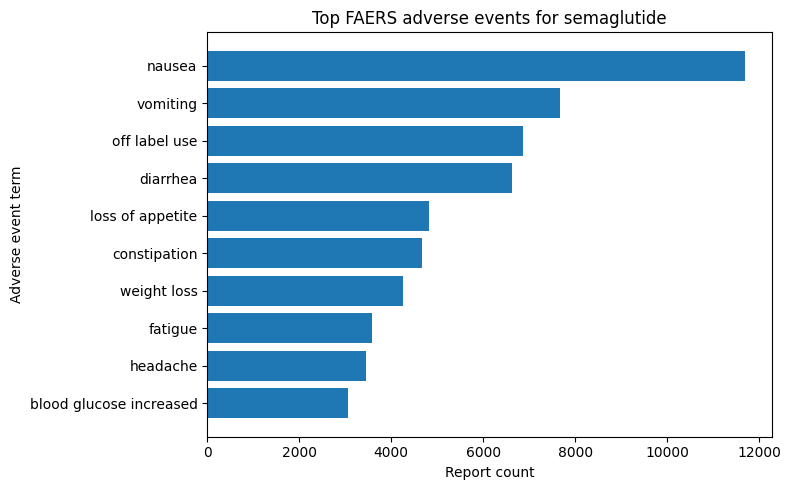

Drug evaluated: semaglutide. Agreement score: 0.048. Divergence score: 0.952. Terms with support from at least three sources: vomiting, diarrhea, constipation, weight loss, fatigue, headache, abdominal pain upper, dizziness, abdominal pain, dyspepsia. Top FAERS signals included: nausea, vomiting, off label use, diarrhea, loss of appetite. Cross-source consistency is limited, so interpretation should be cautious. Many terms are source-specific, which suggests heterogeneity in reporting or extraction.


In [8]:
def build_interpretation(drug_name, master_df, scores):
    if master_df.empty:
        return f"No evidence was retrieved for {drug_name}. Check spelling, aliases, or API availability."

    highly_supported = master_df[master_df["source_count"] >= 3]["term"].tolist()[:10]
    faers_dominant = faers_df.sort_values("count", ascending=False)["term"].tolist()[:5] if not faers_df.empty else []

    lines = [
        f"Drug evaluated: {drug_name}.",
        f"Agreement score: {scores['agreement_score']}.",
        f"Divergence score: {scores['divergence_score']}.",
    ]

    if highly_supported:
        lines.append("Terms with support from at least three sources: " + ", ".join(highly_supported) + ".")
    else:
        lines.append("No terms were supported by three or more sources in this prototype run.")

    if faers_dominant:
        lines.append("Top FAERS signals included: " + ", ".join(faers_dominant) + ".")

    if scores["agreement_score"] >= 0.4:
        lines.append("Overall cross-source consistency appears moderate to strong.")
    else:
        lines.append("Cross-source consistency is limited, so interpretation should be cautious.")

    if scores["divergence_score"] >= 0.5:
        lines.append("Many terms are source-specific, which suggests heterogeneity in reporting or extraction.")
    else:
        lines.append("Source-specific noise is present but not dominant.")

    return " ".join(lines)

summary_columns = ["term", "count", "source_count", "FAERS", "DailyMed", "ClinicalTrials", "PubMed"]
display(master_df[summary_columns].head(20))

if not faers_df.empty:
    chart_df = faers_df.sort_values("count", ascending=False).head(10).sort_values("count")
    plt.figure(figsize=(8, 5))
    plt.barh(chart_df["term"], chart_df["count"])
    plt.title(f"Top FAERS adverse events for {drug_name}")
    plt.xlabel("Report count")
    plt.ylabel("Adverse event term")
    plt.tight_layout()
    plt.show()

print(build_interpretation(drug_name, master_df, scores))


In [9]:
import re
import requests
import certifi
import pandas as pd
import xml.etree.ElementTree as ET
from IPython.display import display # Import display for Jupyter environment compatibility

OPENFDA_URL = "https://api.fda.gov/drug/event.json"
DAILYMED_SEARCH_URL = "https://dailymed.nlm.nih.gov/dailymed/services/v2/spls.json"
DAILYMED_SPL_URL = "https://dailymed.nlm.nih.gov/dailymed/services/v2/spls/{setid}.xml"
CLINICALTRIALS_URL = "https://clinicaltrials.gov/api/v2/studies"
PUBMED_ESEARCH_URL = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
PUBMED_EFETCH_URL = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"

ALIASES = {
    "semaglutide": ["ozempic", "wegovy", "rybelsus"],
    "sertraline": ["zoloft"],
}

COMMON_AE_TERMS = [
    "nausea",
    "vomiting",
    "diarrhea",
    "diarrhoea",
    "headache",
    "fatigue",
    "dizziness",
    "anxiety",
    "depression",
    "constipation",
    "abdominal pain",
    "loss of appetite",
    "decreased appetite",
    "weight loss",
    "insomnia",
    "somnolence",
    "drowsiness",
    "rash",
    "dry mouth",
    "hypoglycemia",
    "suicidal ideation",
    "tremor",
    "dyspepsia",
    "pancreatitis",
    "gastroparesis",
    "cholelithiasis",
    "thyroid neoplasm",
    "acute kidney injury",
]

STOP_PHRASES = {
    "adverse reactions",
    "warnings and precautions",
    "boxed warning",
    "warnings",
    "precautions",
    "most common adverse reactions",
    "common adverse reactions",
    "contraindications",
    "drug interactions",
    "dosage and administration",
}

EXPANDED_EXPANDED_TERM_MAP = {
    "diarrhoea": "diarrhea",
    "weight decreased": "weight loss",
    "decreased appetite": "loss of appetite",
    "drug ineffective": "lack of efficacy",
    "somnolence": "drowsiness",
    "hypoglycaemia": "hypoglycemia",
    "head ache": "headache",
    "drymouth": "dry mouth",
    "abdominal discomfort": "abdominal pain",
    "stomach pain": "abdominal pain",
    "sleepiness": "drowsiness",
    "tiredness": "fatigue",
    "emesis": "vomiting",
}

def normalize_term(term):
    if not isinstance(term, str):
        return ""
    term = term.strip().lower()
    term = re.sub(r"\s+", " ", term)
    term = term.strip(" .,;:()[]{}")
    term = EXPANDED_TERM_MAP.get(term, term)
    return term

def build_search(drug_name):
    drug_name = drug_name.strip().lower()
    terms = [drug_name] + ALIASES.get(drug_name, [])
    quoted_terms = [f'"{term}"' for term in terms]
    search_query = f'patient.drug.medicinalproduct:({" OR ".join(quoted_terms)})'
    return search_query, terms

def fetch_faers_terms(drug_name, top_n=30):
    search_query, matched_terms = build_search(drug_name)

    response = requests.get(
        OPENFDA_URL,
        params={
            "search": search_query,
            "count": "patient.reaction.reactionmeddrapt.exact"
        },
        timeout=30,
        verify=certifi.where()
    )
    response.raise_for_status()
    data = response.json()

    rows = []
    for item in data.get("results", [])[:top_n]:
        rows.append({
            "term": normalize_term(item["term"]),
            "count": item["count"]
        })

    return pd.DataFrame(rows), matched_terms

def get_dailymed_setid(drug_name):
    response = requests.get(
        DAILYMED_SEARCH_URL,
        params={"drug_name": drug_name},
        timeout=30
    )
    response.raise_for_status()
    data = response.json()
    spls = data.get("data", [])
    if not spls:
        return None, None
    first = spls[0]
    return first["setid"], first.get("title", "Unknown Title")

def strip_text(element):
    return " ".join("".join(element.itertext()).split())

def extract_relevant_sections(xml_text):
    root = ET.fromstring(xml_text)
    matched_sections = []
    keywords = ["adverse reactions", "warnings and precautions", "boxed warning"]

    for elem in root.iter():
        if elem.tag.lower().endswith("section"):
            text = strip_text(elem)
            lower_text = text.lower()
            for keyword in keywords:
                if keyword in lower_text[:1500]:
                    matched_sections.append(text)
                    break
    return matched_sections

def clean_candidate(term):
    term = normalize_term(term)
    if len(term) < 3:
        return None
    if term in STOP_PHRASES:
        return None
    if any(char.isdigit() for char in term):
        return None
    if len(term.split()) > 5:
        return None
    return term

def extract_event_terms_from_section(section_text):
    candidates = set()
    pieces = re.split(r"[;,]| and ", section_text)
    for piece in pieces:
        term = clean_candidate(piece)
        if term:
            candidates.add(term)
    return candidates

def fetch_dailymed_terms(drug_name):
    setid, title = get_dailymed_setid(drug_name)
    if not setid:
        return pd.DataFrame(columns=["term"]), title, setid

    response = requests.get(DAILYMED_SPL_URL.format(setid=setid), timeout=30)
    response.raise_for_status()

    sections = extract_relevant_sections(response.text)

    all_terms = set()
    for section in sections:
        all_terms.update(extract_event_terms_from_section(section))

    return pd.DataFrame({"term": sorted(all_terms)}), title, setid

def build_trial_query(drug_name):
    terms = [drug_name.strip().lower()] + ALIASES.get(drug_name.strip().lower(), [])
    ordered_terms = list(dict.fromkeys(term for term in terms if term))
    return " OR ".join(ordered_terms)


def search_trials(drug_name, page_size=TOP_N_TRIALS):
    response = requests.get(
        CLINICALTRIALS_URL,
        params={
            "query.term": build_trial_query(drug_name),
            "pageSize": page_size,
            "format": "json",
        },
        timeout=30,
    )
    response.raise_for_status()
    data = response.json()
    return data.get("studies", [])

def extract_ct_event_terms(event_list):
    terms = set()
    for event in event_list:
        term = event.get("term")
        if term:
            terms.add(normalize_term(term))
    return terms

def fetch_clinicaltrials_terms(drug_name, page_size=TOP_N_TRIALS):
    studies = search_trials(drug_name, page_size=page_size)
    all_terms = set()

    for study in studies:
        results = study.get("resultsSection", {})
        ae_module = results.get("adverseEventsModule", {})
        all_terms.update(extract_ct_event_terms(ae_module.get("seriousEvents", [])))
        all_terms.update(extract_ct_event_terms(ae_module.get("otherEvents", [])))

    return pd.DataFrame({"term": sorted(all_terms)}), studies

def search_pubmed(drug_name, retmax=10):
    response = requests.get(
        PUBMED_ESEARCH_URL,
        params={
            "db": "pubmed",
            "term": f"({drug_name}) AND (adverse events OR side effects OR safety)",
            "retmax": retmax,
            "retmode": "json"
        },
        timeout=30
    )
    response.raise_for_status()
    data = response.json()
    return data["esearchresult"]["idlist"]

def fetch_pubmed_details(pmids):
    if not pmids:
        return []

    response = requests.get(
        PUBMED_EFETCH_URL,
        params={
            "db": "pubmed",
            "id": ",".join(pmids),
            "retmode": "xml"
        },
        timeout=30
    )
    response.raise_for_status()

    root = ET.fromstring(response.text)
    articles = []

    for article in root.findall(".//PubmedArticle"):
        title_elem = article.find(".//ArticleTitle")
        abstract_elems = article.findall(".//AbstractText")
        pmid_elem = article.find(".//PMID")

        title = "".join(title_elem.itertext()).strip() if title_elem is not None else "NA"
        abstract = " ".join("".join(a.itertext()).strip() for a in abstract_elems if a is not None)
        pmid = pmid_elem.text.strip() if pmid_elem is not None else "NA"

        articles.append({
            "pmid": pmid,
            "title": title,
            "abstract": abstract
        })

    return articles

def extract_pubmed_terms(text):
    text_lower = text.lower()
    found = set()
    for term in COMMON_AE_TERMS:
        pattern = r"\b" + re.escape(term) + r"\b"
        if re.search(pattern, text_lower):
            found.add(normalize_term(term))
    return found

def fetch_pubmed_terms(drug_name, retmax=10):
    pmids = search_pubmed(drug_name, retmax=retmax)
    articles = fetch_pubmed_details(pmids)

    all_terms = set()
    for article in articles:
        combined_text = article["title"] + " " + article["abstract"]
        all_terms.update(extract_pubmed_terms(combined_text))

    return pd.DataFrame({"term": sorted(all_terms)}), articles

def normalize_dataframe_terms(df, term_col="term", count_col=None):
    if df is None or df.empty:
        if count_col:
            return pd.DataFrame(columns=["term", count_col])
        return pd.DataFrame(columns=["term"])

    temp = df.copy()
    temp[term_col] = temp[term_col].apply(normalize_term)
    temp = temp[temp[term_col] != ""]

    if count_col and count_col in temp.columns:
        temp = (
            temp.groupby(term_col, as_index=False)[count_col]
            .sum()
            .rename(columns={term_col: "term"})
        )
    else:
        temp = temp[[term_col]].drop_duplicates().rename(columns={term_col: "term"})

    return temp

def build_final_results_table(faers_clean, dailymed_clean, clinicaltrials_clean, pubmed_clean):
    faers_set = set(faers_clean["term"]) if not faers_clean.empty else set()
    dailymed_set = set(dailymed_clean["term"]) if not dailymed_clean.empty else set()
    ct_set = set(clinicaltrials_clean["term"]) if not clinicaltrials_clean.empty else set()
    pubmed_set = set(pubmed_clean["term"]) if not pubmed_clean.empty else set()

    all_terms = sorted(faers_set | dailymed_set | ct_set | pubmed_set)

    rows = []
    for term in all_terms:
        rows.append({
            "term": term,
            "in_faers": term in faers_set,
            "in_dailymed": term in dailymed_set,
            "in_clinicaltrials": term in ct_set,
            "in_pubmed": term in pubmed_set,
        })

    final_df = pd.DataFrame(rows)

    if final_df.empty:
        return final_df

    final_df["source_count"] = final_df[
        ["in_faers", "in_dailymed", "in_clinicaltrials", "in_pubmed"]
    ].sum(axis=1)

    final_df = final_df.merge(
        faers_clean.rename(columns={"count": "faers_count"}),
        on="term",
        how="left"
    )

    final_df["faers_count"] = final_df["faers_count"].fillna(0).astype(int)

    final_df = final_df[
        [
            "term",
            "faers_count",
            "in_faers",
            "in_dailymed",
            "in_clinicaltrials",
            "in_pubmed",
            "source_count",
        ]
    ].sort_values(
        by=["source_count", "faers_count", "term"],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    return final_df

# Define drug_name for self-contained execution
drug_name = "semaglutide"

faers_df, faers_matched_terms = fetch_faers_terms(drug_name, top_n=30)
dailymed_df, dailymed_title, dailymed_setid = fetch_dailymed_terms(drug_name)
clinicaltrials_df, trials_data = fetch_clinicaltrials_terms(drug_name, page_size=TOP_N_TRIALS)
pubmed_df, pubmed_articles = fetch_pubmed_terms(drug_name, retmax=10)

faers_clean = normalize_dataframe_terms(faers_df, term_col="term", count_col="count")
dailymed_clean = normalize_dataframe_terms(dailymed_df, term_col="term")
clinicaltrials_clean = normalize_dataframe_terms(clinicaltrials_df, term_col="term")
pubmed_clean = normalize_dataframe_terms(pubmed_df, term_col="term")

final_results_df = build_final_results_table(
    faers_clean,
    dailymed_clean,
    clinicaltrials_clean,
    pubmed_clean
)

display(final_results_df.head(30))

agreement_score_v2 = round((final_results_df["source_count"] >= 2).mean(), 3) if not final_results_df.empty else 0.0
divergence_score_v2 = round((final_results_df["source_count"] == 1).mean(), 3) if not final_results_df.empty else 0.0

print("Updated agreement score:", agreement_score_v2)
print("Updated divergence score:", divergence_score_v2)

csv_name = f"{drug_name}_final_results_table.csv"
final_results_df.to_csv(csv_name, index=False)
print("Saved CSV:", csv_name)


,term,faers_count,in_faers,in_dailymed,in_clinicaltrials,in_pubmed,source_count
0,vomiting,7662,True,True,True,False,3
1,diarrhea,6617,True,True,True,False,3
2,constipation,4658,True,True,True,False,3
3,weight loss,4257,True,False,True,True,3
4,abdominal pain,4068,True,True,True,False,3
5,fatigue,3589,True,True,True,False,3
6,headache,3442,True,True,True,False,3
7,abdominal pain upper,2965,True,True,True,False,3
8,dizziness,2898,True,True,True,False,3
9,dyspepsia,1694,True,True,True,False,3


Updated agreement score: 0.047
Updated divergence score: 0.953
Saved CSV: semaglutide_final_results_table.csv


In [10]:
# Step 8 interpretation

print("Interpretation:")
print(f"- Normalized final table contains {len(final_results_df)} unique adverse-event terms.")
print(f"- Agreement score after normalization: {agreement_score_v2}")
print(f"- Divergence score after normalization: {divergence_score_v2}")

high_support_terms = final_results_df[final_results_df["source_count"] >= 3]["term"].tolist()
single_source_terms = final_results_df[final_results_df["source_count"] == 1]["term"].tolist()

print(f"- Terms supported by 3 or more sources: {len(high_support_terms)}")
print(f"- Terms supported by only 1 source: {len(single_source_terms)}")

if high_support_terms:
    print("- Stronger cross-source terms:", ", ".join(high_support_terms[:10]))

if divergence_score_v2 > 0.5:
    print("- Interpretation: evidence remains fragmented across sources, so conclusions should be cautious.")
else:
    print("- Interpretation: normalization improved cross-source consistency and the final table is more suitable for dashboarding.")


Interpretation:
- Normalized final table contains 837 unique adverse-event terms.
- Agreement score after normalization: 0.047
- Divergence score after normalization: 0.953
- Terms supported by 3 or more sources: 12
- Terms supported by only 1 source: 798
- Stronger cross-source terms: vomiting, diarrhea, constipation, weight loss, abdominal pain, fatigue, headache, abdominal pain upper, dizziness, dyspepsia
- Interpretation: evidence remains fragmented across sources, so conclusions should be cautious.


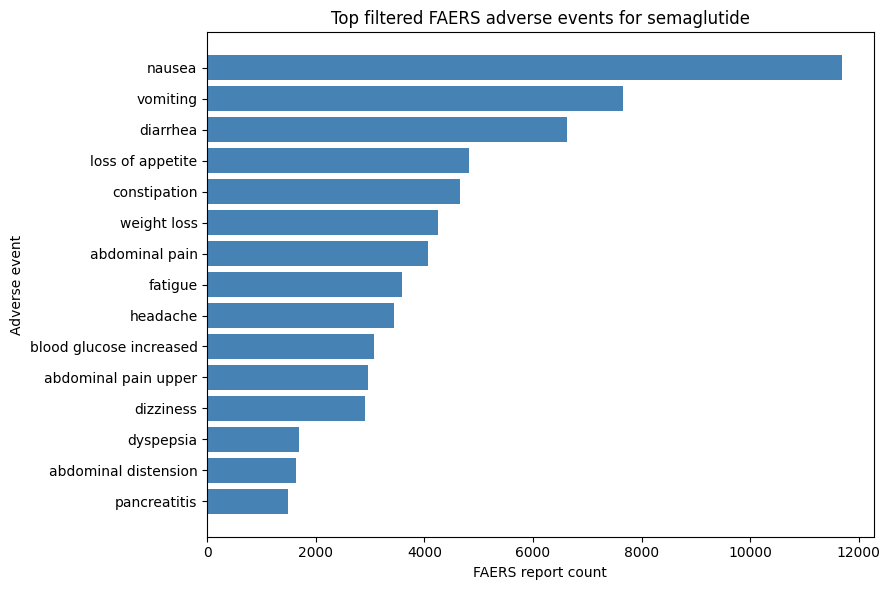

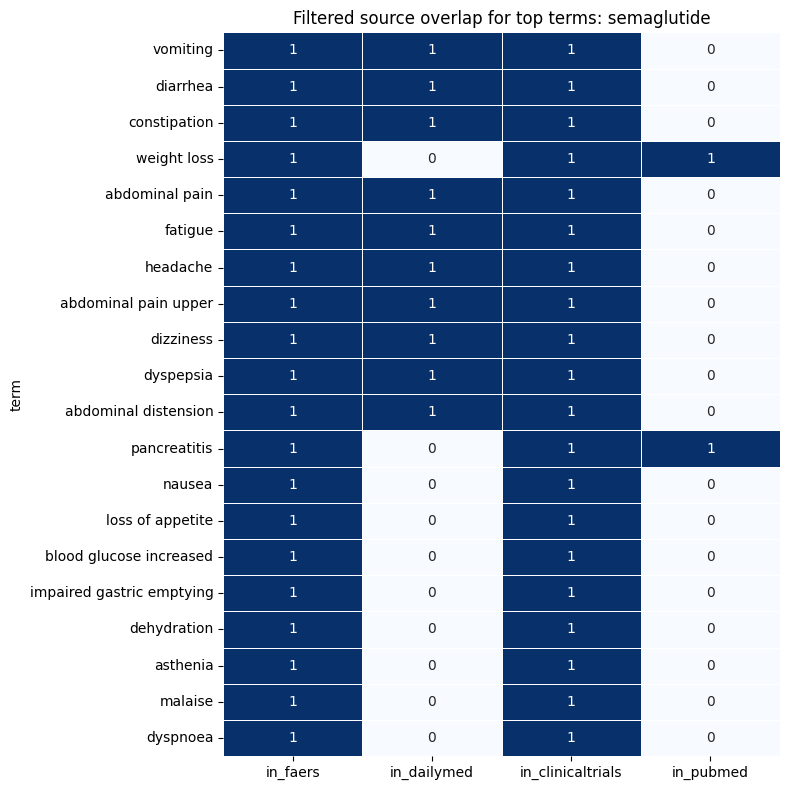


Highly supported terms (3+ sources):


,term,faers_count,in_faers,in_dailymed,in_clinicaltrials,in_pubmed,source_count
0,vomiting,7662,True,True,True,False,3
1,diarrhea,6617,True,True,True,False,3
2,constipation,4658,True,True,True,False,3
3,weight loss,4257,True,False,True,True,3
4,abdominal pain,4068,True,True,True,False,3
5,fatigue,3589,True,True,True,False,3
6,headache,3442,True,True,True,False,3
7,abdominal pain upper,2965,True,True,True,False,3
8,dizziness,2898,True,True,True,False,3
9,dyspepsia,1694,True,True,True,False,3



Moderately supported terms (2 sources):


,term,faers_count,in_faers,in_dailymed,in_clinicaltrials,in_pubmed,source_count
12,nausea,11688,True,False,True,False,2
13,loss of appetite,4817,True,False,True,False,2
14,blood glucose increased,3069,True,False,True,False,2
15,impaired gastric emptying,2806,True,False,True,False,2
16,dehydration,2124,True,False,True,False,2
17,asthenia,2079,True,False,True,False,2
18,malaise,2065,True,False,True,False,2
19,dyspnoea,1610,True,False,True,False,2
20,arthralgia,1460,True,False,True,False,2
21,abdominal pain lower,0,False,True,True,False,2



Single-source terms:


,term,faers_count,in_faers,in_dailymed,in_clinicaltrials,in_pubmed,source_count
38,weight increased,2579,True,False,False,False,1
39,a lump in the neck,0,False,True,False,False,1
40,a mass in the neck,0,False,True,False,False,1
41,abdominal abscess,0,False,False,True,False,1
42,abdominoplasty,0,False,False,True,False,1
43,abnormal dreams,0,False,False,True,False,1
44,abnormal respiration,0,False,True,False,False,1
45,abnormal uterine bleeding,0,False,False,True,False,1
46,abstains from alcohol,0,False,False,True,False,1
47,acne,0,False,False,True,False,1


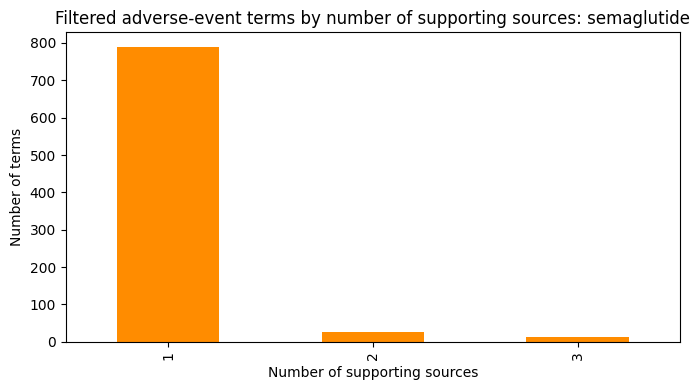


Final interpretation:
For semaglutide, the filtered multi-source table shows an agreement score of 0.046 and a divergence score of 0.954.
Terms with the strongest support across sources include:
- vomiting
- diarrhea
- constipation
- weight loss
- abdominal pain
- fatigue
- headache
- abdominal pain upper
- dizziness
- dyspepsia
Overall interpretation: cross-source consistency remains limited for filtered semaglutide results, so findings should still be treated as exploratory.
A large share of terms remain source-specific even after filtering, suggesting residual terminology differences or incomplete evidence overlap.


In [16]:
# Step 9. Charts and dashboard-style outputs using filtered results

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

if final_results_filtered_df.empty:
    print("No filtered results available. Run Step 11 first.")
else:
    # 1. Top FAERS bar chart
    top_faers_plot = final_results_filtered_df[final_results_filtered_df["faers_count"] > 0].copy()
    top_faers_plot = top_faers_plot.head(15).sort_values("faers_count", ascending=True)

    if not top_faers_plot.empty:
        plt.figure(figsize=(9, 6))
        plt.barh(top_faers_plot["term"], top_faers_plot["faers_count"], color="steelblue")
        plt.title(f"Top filtered FAERS adverse events for {drug_name}")
        plt.xlabel("FAERS report count")
        plt.ylabel("Adverse event")
        plt.tight_layout()
        plt.show()
    else:
        print("No FAERS counts available for plotting.")

    # 2. Source overlap heatmap
    heatmap_df = final_results_filtered_df[
        ["term", "in_faers", "in_dailymed", "in_clinicaltrials", "in_pubmed"]
    ].copy().head(20)

    if not heatmap_df.empty:
        heatmap_data = heatmap_df.set_index("term").astype(int)

        plt.figure(figsize=(8, 8))
        sns.heatmap(
            heatmap_data,
            cmap="Blues",
            cbar=False,
            linewidths=0.5,
            annot=True
        )
        plt.title(f"Filtered source overlap for top terms: {drug_name}")
        plt.tight_layout()
        plt.show()
    else:
        print("No overlap data available for heatmap.")

    # 3. Support tables
    high_support_filtered_df = final_results_filtered_df[final_results_filtered_df["source_count"] >= 3].copy()
    medium_support_filtered_df = final_results_filtered_df[final_results_filtered_df["source_count"] == 2].copy()
    single_source_filtered_df = final_results_filtered_df[final_results_filtered_df["source_count"] == 1].copy()

    print("\nHighly supported terms (3+ sources):")
    if not high_support_filtered_df.empty:
        display(high_support_filtered_df.head(20))
    else:
        print("No terms supported by 3 or more sources.")

    print("\nModerately supported terms (2 sources):")
    if not medium_support_filtered_df.empty:
        display(medium_support_filtered_df.head(20))
    else:
        print("No terms supported by exactly 2 sources.")

    print("\nSingle-source terms:")
    if not single_source_filtered_df.empty:
        display(single_source_filtered_df.head(20))
    else:
        print("No single-source terms found.")

    # 4. Distribution chart
    support_counts = final_results_filtered_df["source_count"].value_counts().sort_index()

    plt.figure(figsize=(7, 4))
    support_counts.plot(kind="bar", color="darkorange")
    plt.title(f"Filtered adverse-event terms by number of supporting sources: {drug_name}")
    plt.xlabel("Number of supporting sources")
    plt.ylabel("Number of terms")
    plt.tight_layout()
    plt.show()

    # 5. Final interpretation block
    print("\nFinal interpretation:")
    print(
        f"For {drug_name}, the filtered multi-source table shows an agreement score of "
        f"{agreement_score_filtered} and a divergence score of {divergence_score_filtered}."
    )

    if not high_support_filtered_df.empty:
        print("Terms with the strongest support across sources include:")
        for term in high_support_filtered_df["term"].head(10):
            print("-", term)
    else:
        print("No terms were supported by 3 or more sources in this filtered run.")

    if agreement_score_filtered >= 0.4:
        print(f"Overall interpretation: there is moderate cross-source consistency in the filtered {drug_name} adverse-event profile.")
    else:
        print(f"Overall interpretation: cross-source consistency remains limited for filtered {drug_name} results, so findings should still be treated as exploratory.")

    if divergence_score_filtered >= 0.5:
        print("A large share of terms remain source-specific even after filtering, suggesting residual terminology differences or incomplete evidence overlap.")
    else:
        print("Divergence is reduced after filtering, suggesting that part of the earlier disagreement was driven by non-clinical FAERS terms.")


In [17]:
# Step 10. Polished final report using filtered results

from IPython.display import Markdown, display

if final_results_filtered_df.empty:
    print("No filtered results available. Run Step 11 first.")
else:
    high_support_filtered_df = final_results_filtered_df[final_results_filtered_df["source_count"] >= 3].copy()
    medium_support_filtered_df = final_results_filtered_df[final_results_filtered_df["source_count"] == 2].copy()
    single_source_filtered_df = final_results_filtered_df[final_results_filtered_df["source_count"] == 1].copy()
    top_faers_filtered_df = final_results_filtered_df[final_results_filtered_df["faers_count"] > 0].copy().head(10)

    report_lines = []

    report_lines.append(f"# {drug_name.title()} Pharmacovigilance Summary")
    report_lines.append("")
    report_lines.append("## Overview")
    report_lines.append(f"- Drug evaluated: **{drug_name}**")
    report_lines.append(f"- Total filtered normalized adverse-event terms: **{len(final_results_filtered_df)}**")
    report_lines.append(f"- Filtered agreement score: **{agreement_score_filtered}**")
    report_lines.append(f"- Filtered divergence score: **{divergence_score_filtered}**")
    report_lines.append("")

    report_lines.append("## Key Findings")
    if not high_support_filtered_df.empty:
        report_lines.append("- Terms supported by 3 or more sources:")
        for term in high_support_filtered_df["term"].head(10):
            report_lines.append(f"  - {term}")
    else:
        report_lines.append("- No terms were supported by 3 or more sources in this filtered run.")

    if not top_faers_filtered_df.empty:
        report_lines.append("- Top filtered FAERS terms:")
        for _, row in top_faers_filtered_df.iterrows():
            report_lines.append(f"  - {row['term']} ({row['faers_count']})")

    report_lines.append("")
    report_lines.append("## Interpretation")

    if agreement_score_filtered >= 0.4:
        report_lines.append(f"- There is moderate cross-source consistency in the filtered {drug_name} adverse-event profile.")
    else:
        report_lines.append(f"- Cross-source consistency remains limited for filtered {drug_name} results, so these findings should be treated as exploratory.")

    if divergence_score_filtered >= 0.5:
        report_lines.append("- Divergence remains high even after filtering, which suggests residual source-specific reporting patterns or incomplete terminology harmonization.")
    else:
        report_lines.append("- Divergence is lower after filtering, indicating that some earlier disagreement was driven by non-clinical or administrative terms.")

    if not medium_support_filtered_df.empty:
        report_lines.append("- Several terms are supported by exactly two sources, which may represent partially aligned safety signals worth follow-up.")

    if not single_source_filtered_df.empty:
        report_lines.append("- Remaining single-source terms should be interpreted cautiously and may benefit from ontology-based grouping or manual review.")

    report_lines.append("")
    report_lines.append("## Source Context")
    report_lines.append("- FAERS reflects spontaneous reporting and signal frequency, not incidence or causality.")
    report_lines.append("- DailyMed reflects regulatory label language.")
    report_lines.append("- ClinicalTrials.gov reflects structured trial result reporting when available.")
    report_lines.append("- PubMed reflects published literature and may use broader narrative terminology.")

    display(Markdown("\n".join(report_lines)))

    print("\nTop highly supported terms table:")
    display(high_support_filtered_df.head(15))

    print("\nTop medium-support terms table:")
    display(medium_support_filtered_df.head(15))

    print("\nTop single-source terms table:")
    display(single_source_filtered_df.head(15))


# Semaglutide Pharmacovigilance Summary

## Overview
- Drug evaluated: **semaglutide**
- Total filtered normalized adverse-event terms: **827**
- Filtered agreement score: **0.046**
- Filtered divergence score: **0.954**

## Key Findings
- Terms supported by 3 or more sources:
  - vomiting
  - diarrhea
  - constipation
  - weight loss
  - abdominal pain
  - fatigue
  - headache
  - abdominal pain upper
  - dizziness
  - dyspepsia
- Top filtered FAERS terms:
  - vomiting (7662)
  - diarrhea (6617)
  - constipation (4658)
  - weight loss (4257)
  - abdominal pain (4068)
  - fatigue (3589)
  - headache (3442)
  - abdominal pain upper (2965)
  - dizziness (2898)
  - dyspepsia (1694)

## Interpretation
- Cross-source consistency remains limited for filtered semaglutide results, so these findings should be treated as exploratory.
- Divergence remains high even after filtering, which suggests residual source-specific reporting patterns or incomplete terminology harmonization.
- Several terms are supported by exactly two sources, which may represent partially aligned safety signals worth follow-up.
- Remaining single-source terms should be interpreted cautiously and may benefit from ontology-based grouping or manual review.

## Source Context
- FAERS reflects spontaneous reporting and signal frequency, not incidence or causality.
- DailyMed reflects regulatory label language.
- ClinicalTrials.gov reflects structured trial result reporting when available.
- PubMed reflects published literature and may use broader narrative terminology.


Top highly supported terms table:


,term,faers_count,in_faers,in_dailymed,in_clinicaltrials,in_pubmed,source_count
0,vomiting,7662,True,True,True,False,3
1,diarrhea,6617,True,True,True,False,3
2,constipation,4658,True,True,True,False,3
3,weight loss,4257,True,False,True,True,3
4,abdominal pain,4068,True,True,True,False,3
5,fatigue,3589,True,True,True,False,3
6,headache,3442,True,True,True,False,3
7,abdominal pain upper,2965,True,True,True,False,3
8,dizziness,2898,True,True,True,False,3
9,dyspepsia,1694,True,True,True,False,3



Top medium-support terms table:


,term,faers_count,in_faers,in_dailymed,in_clinicaltrials,in_pubmed,source_count
12,nausea,11688,True,False,True,False,2
13,loss of appetite,4817,True,False,True,False,2
14,blood glucose increased,3069,True,False,True,False,2
15,impaired gastric emptying,2806,True,False,True,False,2
16,dehydration,2124,True,False,True,False,2
17,asthenia,2079,True,False,True,False,2
18,malaise,2065,True,False,True,False,2
19,dyspnoea,1610,True,False,True,False,2
20,arthralgia,1460,True,False,True,False,2
21,abdominal pain lower,0,False,True,True,False,2



Top single-source terms table:


,term,faers_count,in_faers,in_dailymed,in_clinicaltrials,in_pubmed,source_count
38,weight increased,2579,True,False,False,False,1
39,a lump in the neck,0,False,True,False,False,1
40,a mass in the neck,0,False,True,False,False,1
41,abdominal abscess,0,False,False,True,False,1
42,abdominoplasty,0,False,False,True,False,1
43,abnormal dreams,0,False,False,True,False,1
44,abnormal respiration,0,False,True,False,False,1
45,abnormal uterine bleeding,0,False,False,True,False,1
46,abstains from alcohol,0,False,False,True,False,1
47,acne,0,False,False,True,False,1


filter non-clinical/admin FAERS terms and recompute scores.



In [13]:
# Step 11. Filter non-clinical FAERS terms and recompute final outputs

NON_CLINICAL_TERMS = {
    "off label use",
    "product use in unapproved indication",
    "wrong technique in product usage process",
    "inappropriate schedule of product administration",
    "lack of efficacy",
    "drug interaction",
    "condition aggravated",
    "drug ineffective",
    "illness",
    "death",
    "toxicity to various agents",
    "product dose omission issue",
    "overdose",
    "underdose",
    "medication error",
    "intentional product misuse",
    "accidental overdose",
    "product quality issue",
    "therapeutic response unexpected",
    "feel abnormal",
    "feeling abnormal",
    "fall",
    "pain",   # optional: remove if you want more symptom-specific output
}

def filter_non_clinical_terms(df, term_col="term"):
    if df is None or df.empty:
        return df
    filtered = df[~df[term_col].isin(NON_CLINICAL_TERMS)].copy()
    return filtered.reset_index(drop=True)

faers_filtered = filter_non_clinical_terms(faers_clean, term_col="term")
dailymed_filtered = filter_non_clinical_terms(dailymed_clean, term_col="term")
clinicaltrials_filtered = filter_non_clinical_terms(clinicaltrials_clean, term_col="term")
pubmed_filtered = filter_non_clinical_terms(pubmed_clean, term_col="term")

final_results_filtered_df = build_final_results_table(
    faers_filtered,
    dailymed_filtered,
    clinicaltrials_filtered,
    pubmed_filtered
)

display(final_results_filtered_df.head(30))

agreement_score_filtered = round(
    (final_results_filtered_df["source_count"] >= 2).mean(), 3
) if not final_results_filtered_df.empty else 0.0

divergence_score_filtered = round(
    (final_results_filtered_df["source_count"] == 1).mean(), 3
) if not final_results_filtered_df.empty else 0.0

print("Filtered agreement score:", agreement_score_filtered)
print("Filtered divergence score:", divergence_score_filtered)

csv_name_filtered = f"{drug_name}_final_results_filtered_table.csv"
final_results_filtered_df.to_csv(csv_name_filtered, index=False)
print("Saved filtered CSV:", csv_name_filtered)

high_quality_df = final_results_filtered_df[final_results_filtered_df["source_count"] >= 2].copy()
high_quality_name = f"{drug_name}_high_quality_table.csv"
high_quality_df.to_csv(high_quality_name, index=False)
print("Saved high-quality CSV:", high_quality_name)


,term,faers_count,in_faers,in_dailymed,in_clinicaltrials,in_pubmed,source_count
0,vomiting,7662,True,True,True,False,3
1,diarrhea,6617,True,True,True,False,3
2,constipation,4658,True,True,True,False,3
3,weight loss,4257,True,False,True,True,3
4,abdominal pain,4068,True,True,True,False,3
5,fatigue,3589,True,True,True,False,3
6,headache,3442,True,True,True,False,3
7,abdominal pain upper,2965,True,True,True,False,3
8,dizziness,2898,True,True,True,False,3
9,dyspepsia,1694,True,True,True,False,3


Filtered agreement score: 0.046
Filtered divergence score: 0.954
Saved filtered CSV: semaglutide_final_results_filtered_table.csv
Saved high-quality CSV: semaglutide_high_quality_table.csv


In [14]:
# Step 11 interpretation

high_support_filtered_df = final_results_filtered_df[
    final_results_filtered_df["source_count"] >= 3
].copy()

single_source_filtered_df = final_results_filtered_df[
    final_results_filtered_df["source_count"] == 1
].copy()

print("Filtered interpretation:")
print(f"- Drug evaluated: {drug_name}")
print(f"- Total filtered normalized terms: {len(final_results_filtered_df)}")
print(f"- Filtered agreement score: {agreement_score_filtered}")
print(f"- Filtered divergence score: {divergence_score_filtered}")

if not high_support_filtered_df.empty:
    print("- Strong multi-source terms after filtering:")
    for term in high_support_filtered_df["term"].head(10):
        print("  -", term)

if agreement_score_filtered > agreement_score_v2:
    print("- Agreement improved after removing non-clinical or administrative terms.")
else:
    print("- Agreement did not improve much, suggesting remaining divergence is driven by true source differences or incomplete term mapping.")

if divergence_score_filtered < divergence_score_v2:
    print("- Divergence decreased after filtering, which means part of the earlier divergence was artificial.")
else:
    print("- Divergence remains high, so more synonym mapping or ontology-based grouping may be needed.")


Filtered interpretation:
- Drug evaluated: semaglutide
- Total filtered normalized terms: 827
- Filtered agreement score: 0.046
- Filtered divergence score: 0.954
- Strong multi-source terms after filtering:
  - vomiting
  - diarrhea
  - constipation
  - weight loss
  - abdominal pain
  - fatigue
  - headache
  - abdominal pain upper
  - dizziness
  - dyspepsia
- Agreement did not improve much, suggesting remaining divergence is driven by true source differences or incomplete term mapping.
- Divergence remains high, so more synonym mapping or ontology-based grouping may be needed.
